# Оптимизация доставок CargaPronto: предсказание риска задержки заказа

**Цель проекта.** Построить систему поддержки принятия решений для логистов: в момент оформления заказа модель должна выдавать вероятность задержки доставки, чтобы диспетчер мог заранее сменить приоритет, режим доставки или предупредить клиента.

**Гипотеза.** Задержки вызваны не сбоями логистики, а профилем самих клиентов (география «чёрных дыр» и поведение). Если это так, сегментация базы позволит предсказывать задержку ещё до отправки.

**Задача:** бинарная классификация. 
**Инструменты:** логистическая регрессия и CatBoost. 
**Метрика:** ROC-AUC, целевой порог — **> 0.75**.


##  Импорт библиотек, выполнение базовых настроек

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from catboost import CatBoostClassifier, Pool

import phik

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Библиотеки загружены. RANDOM_STATE =", RANDOM_STATE)

Библиотеки загружены. RANDOM_STATE = 42


In [5]:
# Минимальный набор зависимостей проекта (без жёсткой фиксации версий — пусть pip
# подберёт совместимые с установленным Python).
requirements = """
pandas
numpy
scikit-learn>=1.6
lightgbm
catboost
optuna
shap
sqlalchemy
psycopg2-binary
matplotlib
seaborn
""".strip()

In [7]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [8]:
# Установим зависимости

!pip install -r requirements.txt -qqq 

## Загрузка данных, первичное знакомство

In [6]:
# Загрузка данных
# Сначала пробуем прочитать файл из локального каталога; если его нет —
# скачиваем с удалённого сервера по ссылке.

LOCAL_DIRS = [".", "/datasets"]                       # локальные каталоги
REMOTE_BASE = "https://code.s3.yandex.net/datasets"   # удалённый сервер
FILES = {"customers": "ds_s18_customers.csv",
         "orders":    "ds_s18_orders.csv"}


def load_local(name):
    """Загрузка из локального каталога."""
    fname = FILES[name]
    for d in LOCAL_DIRS:
        path = os.path.join(d, fname)
        if os.path.exists(path):
            print(f"[{name}] локальная загрузка: {path}")
            return pd.read_csv(path)
    return None


def load_remote(name):
    """Загрузка с удалённого сервера по ссылке."""
    url = f"{REMOTE_BASE}/{FILES[name]}"
    print(f"[{name}] удалённая загрузка: {url}")
    return pd.read_csv(url)


def load_dataset(name):
    """Сначала локально, при отсутствии файла — с удалённого сервера."""
    df = load_local(name)
    if df is None:
        df = load_remote(name)
    return df


df_customers = load_dataset("customers")
df_orders = load_dataset("orders")

print("\nРазмерности: customers =", df_customers.shape, "| orders =", df_orders.shape)
display(df_customers.head())
display(df_orders.head())

[customers] локальная загрузка: ./ds_s18_customers.csv
[orders] локальная загрузка: ./ds_s18_orders.csv

Размерности: customers = (20652, 8) | orders = (180519, 7)


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


**Проверка данных, дубликаты и признаки даты/времени.**

In [9]:
# Информация по данным и пропускам
print("=== customers.info() ==="); df_customers.info()
print("\n=== orders.info() ==="); df_orders.info()
print("\nПропуски customers:\n", df_customers.isna().sum())
print("\nПропуски orders:\n", df_orders.isna().sum())
display(df_customers.describe().T)
display(df_orders.describe(include="all").T)

# Полные дубликаты строк 
print("\nПолных дубликатов: customers =", df_customers.duplicated().sum(),
      "| orders =", df_orders.duplicated().sum())
print("Дубликатов customer_id в справочнике:", df_customers["customer_id"].duplicated().sum())
df_customers = df_customers.drop_duplicates().reset_index(drop=True)
df_orders = df_orders.drop_duplicates().reset_index(drop=True)

# --- Признаки даты и времени ---
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders["order_month"]   = df_orders["order_date"].dt.month
df_orders["order_weekday"] = df_orders["order_date"].dt.weekday   
df_orders["order_hour"]    = df_orders["order_date"].dt.hour
print("\nПериод заказов:", df_orders["order_date"].min(), "—", df_orders["order_date"].max())
display(df_orders[["order_date", "order_month", "order_weekday", "order_hour"]].head())

=== customers.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB

=== orders.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       1

,count,mean,std,min,25%,50%,75%,max
customer_id,20652.0,10400.285929,5993.106225,1.000000,5208.750000,10407.500000,15594.250000,20757.000000
customer_lat,20652.0,29.748733,9.824123,-33.937553,18.266061,33.216427,39.292240,48.781933
customer_lon,20652.0,-84.950080,21.253858,-158.025986,-98.469292,-76.759605,-66.370552,115.263077
total_sales,20652.0,1600.542436,1508.417956,8.470000,254.940002,1294.504997,2621.140007,9436.610088
total_orders,20652.0,3.183808,2.430699,1.000000,1.000000,3.000000,5.000000,15.000000
avg_discount,20652.0,0.101707,0.048256,0.000000,0.076250,0.100000,0.123000,0.250000
return_rate,20652.0,0.042966,0.156606,0.000000,0.000000,0.000000,0.000000,1.000000
recency,20652.0,221.089144,199.395441,1.000000,76.000000,160.000000,308.000000,1126.000000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,180519.0,NaN,NaN,NaN,90260.0,52111.490959,1.0,45130.5,90260.0,135389.5,180519.0
customer_id,180519.0,NaN,NaN,NaN,6691.379495,4162.918106,1.0,3258.5,6457.0,9779.0,20757.0
late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
shipping_mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,180519,65752,2016-10-25 14:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,180519.0,NaN,NaN,NaN,141.23255,139.732492,9.99,50.0,59.990002,199.990005,1999.98999



Полных дубликатов: customers = 0 | orders = 0
Дубликатов customer_id в справочнике: 0

Период заказов: 2015-01-01 00:00:00 — 2018-01-31 23:38:00


,order_date,order_month,order_weekday,order_hour
0,2018-01-31 22:56:00,1,2,22
1,2018-01-13 12:27:00,1,5,12
2,2018-01-13 12:06:00,1,5,12
3,2018-01-13 11:45:00,1,5,11
4,2018-01-13 11:24:00,1,5,11


## EDA

Доли классов late_delivery_risk:
late_delivery_risk
0    0.452
1    0.548
Name: proportion, dtype: float64
Доля задержек: 54.8%  (аудит сообщал о ~55%)


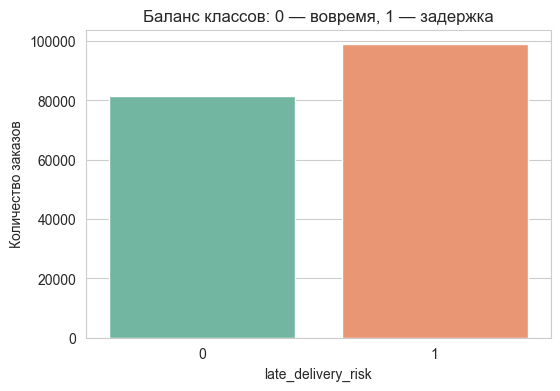

In [10]:
# 1) Баланс классов целевой переменной
balance = df_orders["late_delivery_risk"].value_counts(normalize=True).sort_index()
print("Доли классов late_delivery_risk:")
print(balance.round(3))
print(f"Доля задержек: {balance.get(1, 0):.1%}  (аудит сообщал о ~55%)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="late_delivery_risk", data=df_orders, palette="Set2", ax=ax)
ax.set_title("Баланс классов: 0 — вовремя, 1 — задержка")
ax.set_xlabel("late_delivery_risk"); ax.set_ylabel("Количество заказов")
plt.show()

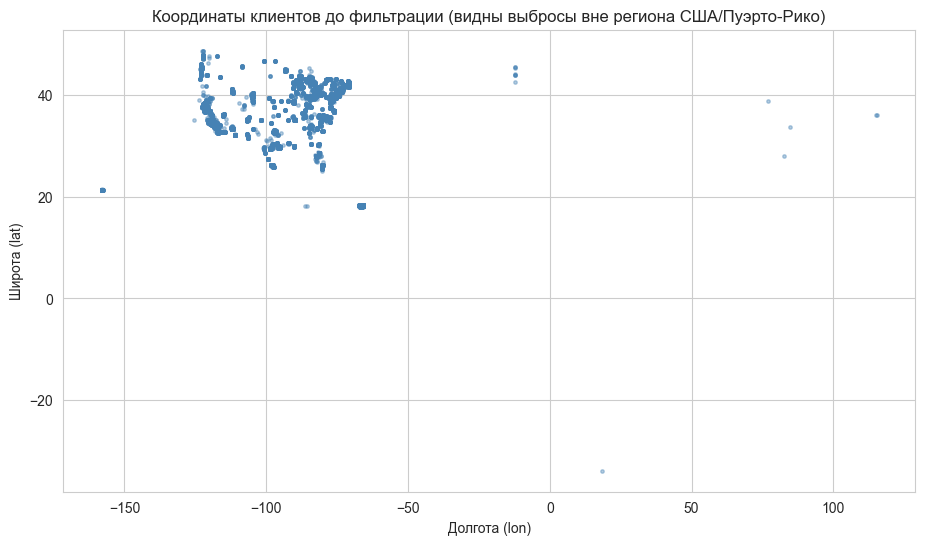

Диапазон долготы до фильтрации: -158.03 ... 115.26

Аномальных клиентов по долготе: 156
Удалено заказов вместе с аномальными клиентами: 1430
Размерности после фильтрации: customers = (20496, 8) | orders = (179089, 10)


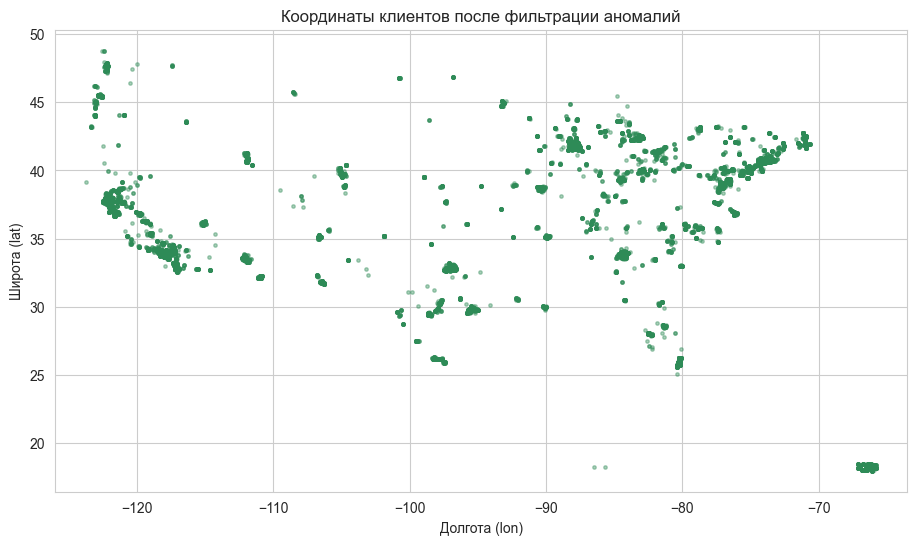

In [11]:
# 2) Географический аудит — карта координат до фильтрации
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(df_customers["customer_lon"], df_customers["customer_lat"],
           s=6, alpha=0.4, color="steelblue")
ax.set_title("Координаты клиентов до фильтрации (видны выбросы вне региона США/Пуэрто-Рико)")
ax.set_xlabel("Долгота (lon)"); ax.set_ylabel("Широта (lat)")
plt.show()
print("Диапазон долготы до фильтрации:",
      df_customers["customer_lon"].min().round(2), "...", df_customers["customer_lon"].max().round(2))

# 3) Удаление географических аномалий по долготе [-125, -20]
LON_MIN, LON_MAX = -125, -20
anomaly_mask = (df_customers["customer_lon"] < LON_MIN) | (df_customers["customer_lon"] > LON_MAX)
bad_customers = set(df_customers.loc[anomaly_mask, "customer_id"])
print(f"\nАномальных клиентов по долготе: {len(bad_customers)}")

# Контроль целостности: удаляем профиль -> удаляем и все его заказы
df_customers = df_customers[~anomaly_mask].reset_index(drop=True)
before = len(df_orders)
df_orders = df_orders[~df_orders["customer_id"].isin(bad_customers)].reset_index(drop=True)
print(f"Удалено заказов вместе с аномальными клиентами: {before - len(df_orders)}")
print("Размерности после фильтрации: customers =", df_customers.shape, "| orders =", df_orders.shape)

# Карта после фильтрации
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(df_customers["customer_lon"], df_customers["customer_lat"],
           s=6, alpha=0.4, color="seagreen")
ax.set_title("Координаты клиентов после фильтрации аномалий")
ax.set_xlabel("Долгота (lon)"); ax.set_ylabel("Широта (lat)")
ax.axis("equal")
plt.show()

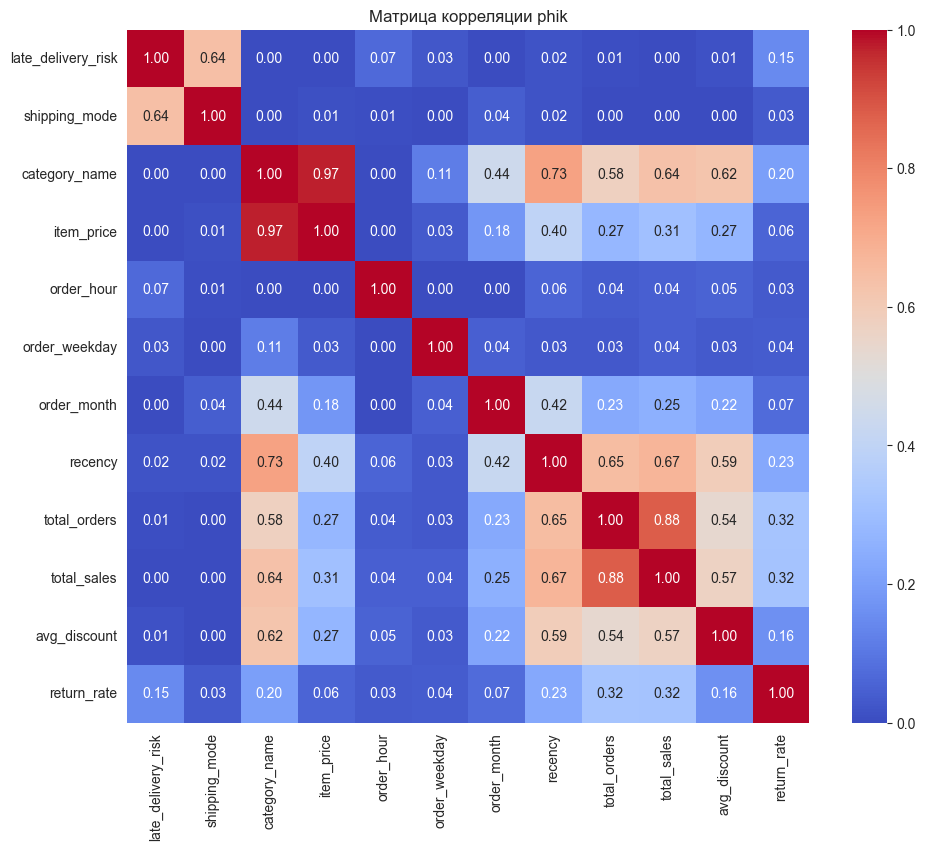

Связь признаков с целевой переменной (phik), по убыванию:
shipping_mode    0.644
return_rate      0.147
order_hour       0.067
order_weekday    0.025
recency          0.016
avg_discount     0.012
total_orders     0.006
category_name    0.000
item_price       0.000
order_month      0.000
total_sales      0.000
Name: late_delivery_risk, dtype: float64


In [12]:
# Корреляционный анализ (phik) 
# Строим на заказах, обогащённых поведенческими признаками клиента (на выборке для скорости).
eda = df_orders.merge(
    df_customers[["customer_id", "recency", "total_orders", "total_sales",
                  "avg_discount", "return_rate"]],
    on="customer_id", how="left")

phik_cols = ["late_delivery_risk", "shipping_mode", "category_name", "item_price",
             "order_hour", "order_weekday", "order_month",
             "recency", "total_orders", "total_sales", "avg_discount", "return_rate"]
interval_cols = ["item_price", "order_hour", "order_weekday", "order_month",
                 "recency", "total_orders", "total_sales", "avg_discount", "return_rate"]

sample = eda[phik_cols].sample(n=min(12000, len(eda)), random_state=RANDOM_STATE)
phik_matrix = sample.phik_matrix(interval_cols=interval_cols)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, ax=ax)
ax.set_title("Матрица корреляции phik")
plt.show()

print("Связь признаков с целевой переменной (phik), по убыванию:")
print(phik_matrix["late_delivery_risk"].drop("late_delivery_risk").sort_values(ascending=False).round(3))

##  Разделение на выборки

In [16]:
# Заказы одного клиента не должны попасть в разные выборки
# Группируем по customer_id с помощью GroupShuffleSplit.

df_orders = df_orders.reset_index(drop=True)
groups = df_orders["customer_id"]

# Шаг 1: отделяем 40% клиентов (val+test) от 60% (train)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(df_orders, groups=groups))

# Шаг 2: оставшиеся 40% делим пополам -> val 20% и test 20%
temp = df_orders.iloc[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val_rel, test_rel = next(gss2.split(temp, groups=temp["customer_id"]))
val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

df_train = df_orders.iloc[train_idx].reset_index(drop=True)
df_val   = df_orders.iloc[val_idx].reset_index(drop=True)
df_test  = df_orders.iloc[test_idx].reset_index(drop=True)

n = len(df_orders)
print(f"train: {len(df_train):>7} ({len(df_train)/n:.1%}) | "
      f"val: {len(df_val):>7} ({len(df_val)/n:.1%}) | "
      f"test: {len(df_test):>7} ({len(df_test)/n:.1%})")

# Проверка непересечения клиентов
s_tr, s_va, s_te = set(df_train.customer_id), set(df_val.customer_id), set(df_test.customer_id)
print("Пересечение train∩val :", len(s_tr & s_va))
print("Пересечение train∩test:", len(s_tr & s_te))
print("Пересечение val∩test  :", len(s_va & s_te))
print("Клиенты в выборках не пересекаются.")

# Баланс целевой по выборкам
for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name}: доля задержек = {d['late_delivery_risk'].mean():.3f}")

train:  107721 (60.1%) | val:   35355 (19.7%) | test:   36013 (20.1%)
Пересечение train∩val : 0
Пересечение train∩test: 0
Пересечение val∩test  : 0
Клиенты в выборках не пересекаются.
train: доля задержек = 0.548
val: доля задержек = 0.550
test: доля задержек = 0.548


## Обучение базовой модели

In [18]:
BASE_NUM = ["item_price", "order_hour", "order_weekday", "order_month"]
BASE_CAT = ["shipping_mode", "category_name"]
TARGET = "late_delivery_risk"

def xy(df, num, cat):
    return df[num + cat].copy(), df[TARGET].copy()

X_train, y_train = xy(df_train, BASE_NUM, BASE_CAT)
X_val,   y_val   = xy(df_val,   BASE_NUM, BASE_CAT)

results = {}   # хранилище ROC-AUC по всем экспериментам

# ---- Логистическая регрессия ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), BASE_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), BASE_CAT),
])
logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
auc_lr_base = roc_auc_score(y_val, logreg.predict_proba(X_val)[:, 1])
results["LogReg (base)"] = auc_lr_base
print(f"Логистическая регрессия (base), ROC-AUC val: {auc_lr_base:.4f}")

# ---- CatBoost ----
def make_catboost(iterations=250, depth=6, learning_rate=0.05):
    return CatBoostClassifier(
        iterations=iterations, depth=depth, learning_rate=learning_rate,
        eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
        early_stopping_rounds=30, thread_count=-1)

cb_base = make_catboost()
cb_base.fit(X_train, y_train, cat_features=BASE_CAT,
            eval_set=(X_val, y_val), use_best_model=True)
auc_cb_base = roc_auc_score(y_val, cb_base.predict_proba(X_val)[:, 1])
results["CatBoost (base)"] = auc_cb_base
print(f"CatBoost (base), ROC-AUC val: {auc_cb_base:.4f}")

# ---- Доп. задание: базовая оптимизация CatBoost (перебор глубины/итераций) ----
best_cfg, best_auc = None, -1
for depth in [6, 8]:
    for it in [250]:
        m = make_catboost(iterations=it, depth=depth)
        m.fit(X_train, y_train, cat_features=BASE_CAT,
              eval_set=(X_val, y_val), use_best_model=True)
        a = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
        if a > best_auc:
            best_auc, best_cfg = a, {"depth": depth, "iterations": it}
print(f"\nЛучшая базовая конфигурация CatBoost: {best_cfg}, ROC-AUC val = {best_auc:.4f}")
results["CatBoost (base, tuned)"] = best_auc
CB_PARAMS = best_cfg  # используем дальше для сравнения с новыми признаками

print("\nИтоги базового этапа (ROC-AUC val):")
for k, v in results.items():
    print(f"  {k:<26} {v:.4f}")

Логистическая регрессия (base), ROC-AUC val: 0.7343
CatBoost (base), ROC-AUC val: 0.7618

Лучшая базовая конфигурация CatBoost: {'depth': 8, 'iterations': 250}, ROC-AUC val = 0.7634

Итоги базового этапа (ROC-AUC val):
  LogReg (base)              0.7343
  CatBoost (base)            0.7618
  CatBoost (base, tuned)     0.7634


##  Кластеризация по признакам, связанным с местоположением



Клиентов для обучения гео-кластеризации (train): 12297


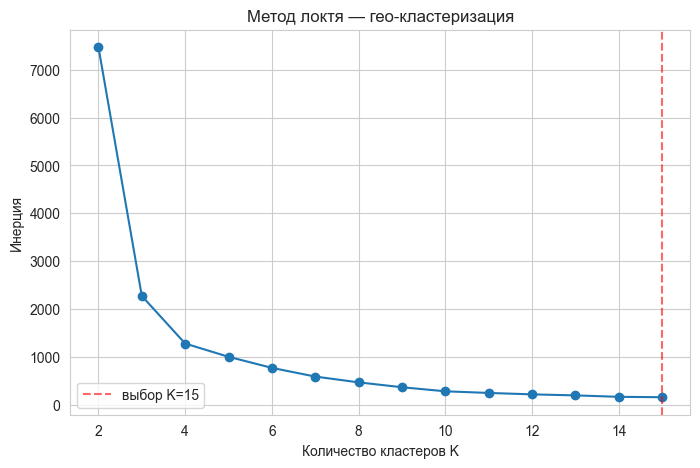

Гео-кластеров: 15. Распределение:
geo_cluster
0     7867
1     1246
2     2560
3      470
4     2642
5      285
6      411
7     1072
8     1003
9      310
10     677
11     471
12     371
13     551
14     560
Name: count, dtype: int64


In [19]:
# Защита от утечки: Scaler и KMeans обучаем на клиентах из train-выборки,
# затем присваиваем кластеры всем клиентам.

GEO_FEATURES = ["customer_lat", "customer_lon"]
train_customer_ids = set(df_train["customer_id"])

cust_train = df_customers[df_customers["customer_id"].isin(train_customer_ids)]
print("Клиентов для обучения гео-кластеризации (train):", len(cust_train))

# KMeans основан на расстояниях -> координаты масштабируем
geo_scaler = StandardScaler().fit(cust_train[GEO_FEATURES])
Xgeo_train = geo_scaler.transform(cust_train[GEO_FEATURES])
Xgeo_all   = geo_scaler.transform(df_customers[GEO_FEATURES])

# Метод локтя
ks = range(2, 16)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=5, random_state=RANDOM_STATE)
    km.fit(Xgeo_train)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks), inertias, "o-")
ax.set_title("Метод локтя — гео-кластеризация")
ax.set_xlabel("Количество кластеров K"); ax.set_ylabel("Инерция")
ax.axvline(15, color="red", ls="--", alpha=0.6, label="выбор K=15")
ax.legend(); plt.show()

GEO_K = 15  # обоснованный методом локтя выбор
geo_km = KMeans(n_clusters=GEO_K, init="k-means++", n_init=5, random_state=RANDOM_STATE)
geo_km.fit(Xgeo_train)
df_customers["geo_cluster"] = geo_km.predict(Xgeo_all)
print(f"Гео-кластеров: {GEO_K}. Распределение:")
print(df_customers["geo_cluster"].value_counts().sort_index())

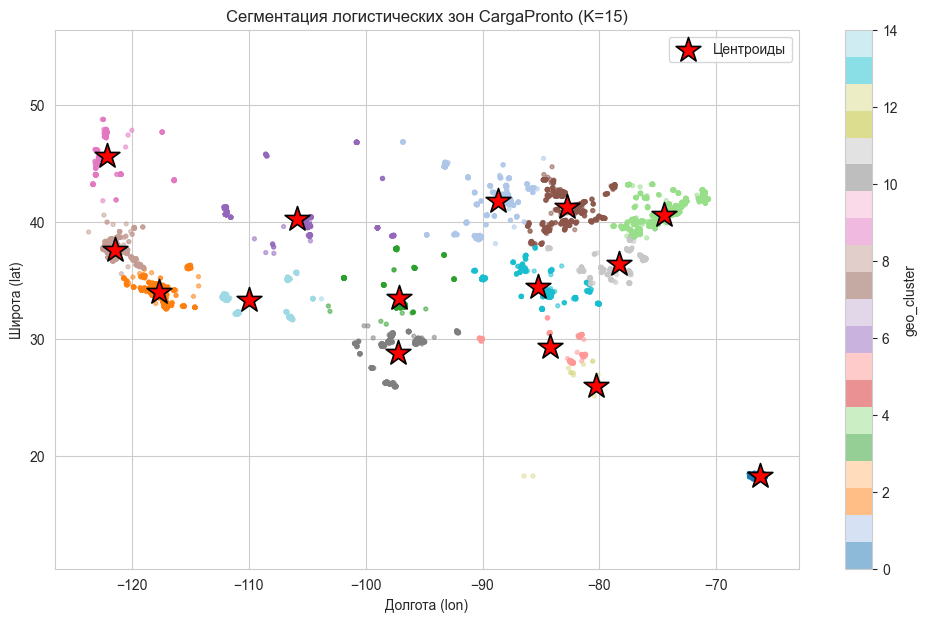

In [22]:
# Карта логистических зон с центроидами (в исходных координатах)
centroids = geo_scaler.inverse_transform(geo_km.cluster_centers_)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(df_customers["customer_lon"], df_customers["customer_lat"],
                c=df_customers["geo_cluster"], cmap="tab20", s=8, alpha=0.5)
ax.scatter(centroids[:, 1], centroids[:, 0],
           marker="*", s=350, c="red", edgecolor="black", linewidth=1.2,
           label="Центроиды", zorder=5)
ax.set_title(f"Сегментация логистических зон CargaPronto (K={GEO_K})")
ax.set_xlabel("Долгота (lon)"); ax.set_ylabel("Широта (lat)")
ax.axis("equal")
ax.legend()
plt.colorbar(sc, ax=ax, label="geo_cluster")
plt.show()

##  Кластеризация по признакам профилей клиентов



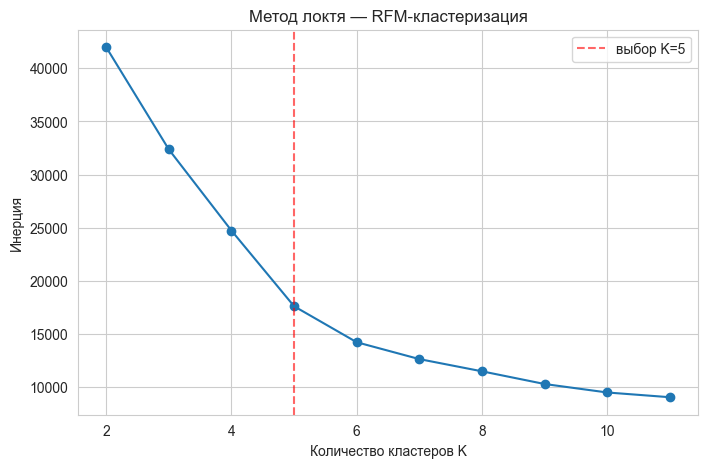

Средние значения признаков по поведенческим кластерам:


,recency,total_orders,total_sales,return_rate,avg_discount,size
beh_cluster,,,,,,
0,157.87,1.38,519.51,0.92,0.10,489
1,517.56,3.07,1555.17,0.03,0.10,4089
2,76.63,1.15,326.52,0.00,0.17,3933
3,235.84,5.98,3296.84,0.04,0.10,6931
4,79.38,1.20,404.10,0.00,0.05,5054


In [23]:
# Признаки в разных единицах (дни, шт., $, %) -> обязательное масштабирование.
# Защита от утечки: Scaler и KMeans обучаем только на train-клиентах.

RFM_FEATURES = ["recency", "total_orders", "total_sales", "return_rate", "avg_discount"]

rfm_scaler = StandardScaler().fit(cust_train[RFM_FEATURES])
Xrfm_train = rfm_scaler.transform(cust_train[RFM_FEATURES])
Xrfm_all   = rfm_scaler.transform(df_customers[RFM_FEATURES])

# Метод локтя
ks = range(2, 12)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=5, random_state=RANDOM_STATE)
    km.fit(Xrfm_train)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks), inertias, "o-")
ax.set_title("Метод локтя — RFM-кластеризация")
ax.set_xlabel("Количество кластеров K"); ax.set_ylabel("Инерция")
ax.axvline(5, color="red", ls="--", alpha=0.6, label="выбор K=5")
ax.legend(); plt.show()

RFM_K = 5
rfm_km = KMeans(n_clusters=RFM_K, init="k-means++", n_init=5, random_state=RANDOM_STATE)
rfm_km.fit(Xrfm_train)
df_customers["beh_cluster"] = rfm_km.predict(Xrfm_all)

# Характеристика кластеров — средние значения признаков
profile = df_customers.groupby("beh_cluster")[RFM_FEATURES].mean()
profile["size"] = df_customers["beh_cluster"].value_counts().sort_index()
print("Средние значения признаков по поведенческим кластерам:")
display(profile.round(2))

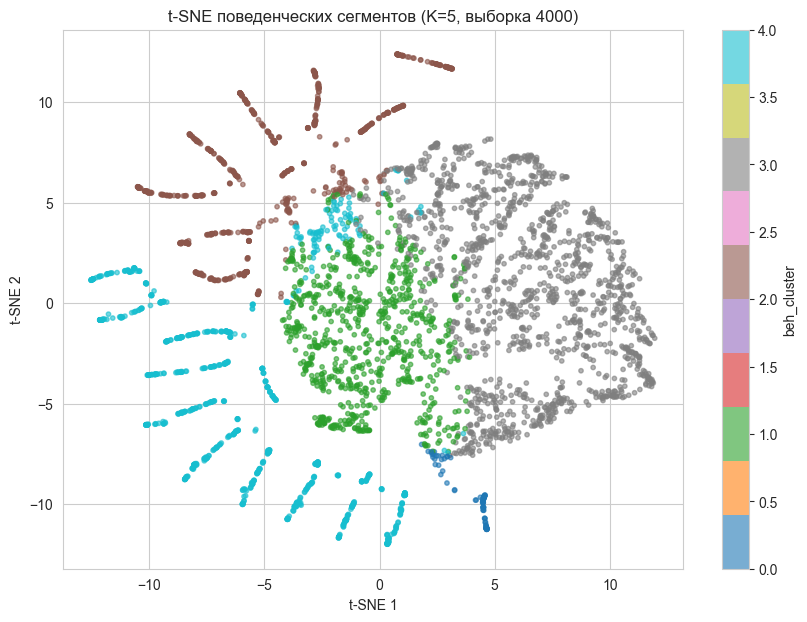

In [24]:
# Визуализация поведенческих кластеров методом t-SNE 
sample_n = min(4000, len(df_customers))
samp = df_customers.sample(n=sample_n, random_state=RANDOM_STATE)
Xrfm_samp = rfm_scaler.transform(samp[RFM_FEATURES])

tsne = TSNE(n_components=2, perplexity=30, init="pca",
            random_state=RANDOM_STATE, max_iter=300)
emb = tsne.fit_transform(Xrfm_samp)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=samp["beh_cluster"],
                cmap="tab10", s=10, alpha=0.6)
ax.set_title(f"t-SNE поведенческих сегментов (K={RFM_K}, выборка {sample_n})")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="beh_cluster")
plt.show()

##  Обучение модели на новых признаках

In [25]:
# --- Обучение моделей с новыми признаками geo_cluster и beh_cluster ---
cluster_map = df_customers[["customer_id", "geo_cluster", "beh_cluster"]]

def add_clusters(df):
    out = df.merge(cluster_map, on="customer_id", how="left")
    assert out[["geo_cluster", "beh_cluster"]].isna().sum().sum() == 0, "Появились пропуски при merge!"
    return out

df_train_x = add_clusters(df_train)
df_val_x   = add_clusters(df_val)
df_test_x  = add_clusters(df_test)
print("Пропусков после merge нет. Пример:")
display(df_train_x[["customer_id", "geo_cluster", "beh_cluster"]].head())

NUM = BASE_NUM
CAT = BASE_CAT
NEW_CAT = ["geo_cluster", "beh_cluster"]

Xtr, ytr = df_train_x[NUM + CAT + NEW_CAT], df_train_x[TARGET]
Xva, yva = df_val_x[NUM + CAT + NEW_CAT],   df_val_x[TARGET]

# ---- Логистическая регрессия: кластеры как категориальные (OHE) ----
prep_new = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT + NEW_CAT),
])
logreg_new = Pipeline([("prep", prep_new),
                       ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
logreg_new.fit(Xtr, ytr)
auc_lr_new = roc_auc_score(yva, logreg_new.predict_proba(Xva)[:, 1])
results["LogReg (new feats)"] = auc_lr_new
print(f"LogReg + кластеры, ROC-AUC val: {auc_lr_new:.4f}")

# ---- CatBoost: те же гиперпараметры, что в базе (чистое сравнение), кластеры как категории ----
cb_new = make_catboost(**CB_PARAMS)
cb_new.fit(Xtr, ytr, cat_features=CAT + NEW_CAT,
           eval_set=(Xva, yva), use_best_model=True)
auc_cb_new = roc_auc_score(yva, cb_new.predict_proba(Xva)[:, 1])
results["CatBoost (new, cat)"] = auc_cb_new
print(f"CatBoost + кластеры (как категории), ROC-AUC val: {auc_cb_new:.4f}")

print("\nСравнение с базой:")
print(f"  CatBoost base : {results['CatBoost (base, tuned)']:.4f}")
print(f"  CatBoost +кл. : {auc_cb_new:.4f}  (прирост {auc_cb_new - results['CatBoost (base, tuned)']:+.4f})")

Пропусков после merge нет. Пример:


,customer_id,geo_cluster,beh_cluster
0,20755,0,4
1,19492,0,4
2,19491,8,4
3,19490,2,4
4,19489,0,4


LogReg + кластеры, ROC-AUC val: 0.7414
CatBoost + кластеры (как категории), ROC-AUC val: 0.7701

Сравнение с базой:
  CatBoost base : 0.7634
  CatBoost +кл. : 0.7701  (прирост +0.0067)


## Дополнительное задание — подбор лучшего количества кластеров

In [27]:
# --- Кластеры как категориальные vs как числовые признаки в CatBoost ---
cb_num = make_catboost(**CB_PARAMS)
cb_num.fit(Xtr, ytr, cat_features=CAT,  # кластеры НЕ в cat_features -> числовые
           eval_set=(Xva, yva), use_best_model=True)
auc_cb_numeric = roc_auc_score(yva, cb_num.predict_proba(Xva)[:, 1])
results["CatBoost (new, numeric)"] = auc_cb_numeric
print(f"CatBoost, кластеры как категории : {results['CatBoost (new, cat)']:.4f}")
print(f"CatBoost, кластеры как числа     : {auc_cb_numeric:.4f}")

# --- Подбор числа кластеров (geo_k, rfm_k) по ROC-AUC на валидации ---

geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]

def build_clusters(geo_k, rfm_k):
    """Переобучает кластеризации на train-клиентах и возвращает карту меток для всех клиентов."""
    gkm = KMeans(n_clusters=geo_k, init="k-means++", n_init=5, random_state=RANDOM_STATE).fit(Xgeo_train)
    rkm = KMeans(n_clusters=rfm_k, init="k-means++", n_init=5, random_state=RANDOM_STATE).fit(Xrfm_train)
    m = df_customers[["customer_id"]].copy()
    m["geo_cluster"] = gkm.predict(Xgeo_all)
    m["beh_cluster"] = rkm.predict(Xrfm_all)
    return m

search = []
for gk in geo_k_range:
    for rk in rfm_k_range:
        cmap = build_clusters(gk, rk)
        tr = df_train.merge(cmap, on="customer_id", how="left")
        va = df_val.merge(cmap, on="customer_id", how="left")
        Xt, yt = tr[NUM + CAT + NEW_CAT], tr[TARGET]
        Xv, yv = va[NUM + CAT + NEW_CAT], va[TARGET]
        m = make_catboost(iterations=150, depth=CB_PARAMS["depth"])
        m.fit(Xt, yt, cat_features=CAT + NEW_CAT, eval_set=(Xv, yv), use_best_model=True)
        a = roc_auc_score(yv, m.predict_proba(Xv)[:, 1])
        search.append({"geo_k": gk, "rfm_k": rk, "roc_auc": a})

search_df = pd.DataFrame(search).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("\nПодбор числа кластеров (ROC-AUC val):")
display(search_df)

best_row = search_df.iloc[0]
BEST_GEO_K = int(best_row["geo_k"]); BEST_RFM_K = int(best_row["rfm_k"])
print(f"\nЛучшая комбинация: geo_k={BEST_GEO_K}, rfm_k={BEST_RFM_K}, ROC-AUC val={best_row['roc_auc']:.4f}")
results["CatBoost (new, tuned K)"] = float(best_row["roc_auc"])

CatBoost, кластеры как категории : 0.7701
CatBoost, кластеры как числа     : 0.7671

Подбор числа кластеров (ROC-AUC val):


,geo_k,rfm_k,roc_auc
0,12,30,0.778350
1,8,30,0.778327
2,4,30,0.778072
3,20,30,0.777919
4,12,20,0.777104
5,4,20,0.776638
6,20,20,0.776606
7,8,20,0.775723
8,12,12,0.774977
9,4,12,0.773785



Лучшая комбинация: geo_k=12, rfm_k=30, ROC-AUC val=0.7784


## Тестирование лучшей модели

ROC-AUC на TEST: 0.7716  (целевой порог 0.75 -> Достигнут)


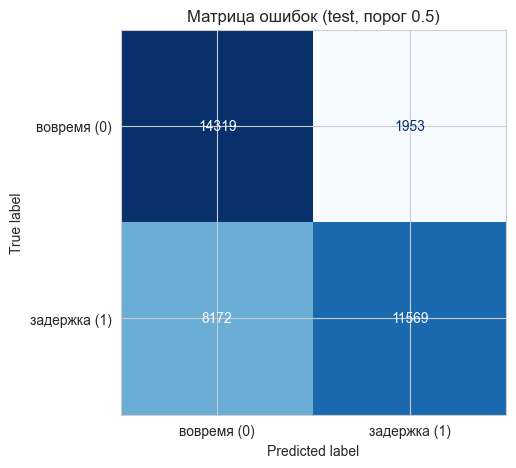

TN=14319  FP=1953  FN=8172  TP=11569
Пропущенные задержки (FN): 8172  |  Ложные тревоги (FP): 1953


In [28]:
# Берём лучшую комбинацию числа кластеров, переобучаем кластеризации и финальный CatBoost.
best_map = build_clusters(BEST_GEO_K, BEST_RFM_K)

tr = df_train.merge(best_map, on="customer_id", how="left")
va = df_val.merge(best_map, on="customer_id", how="left")
te = df_test.merge(best_map, on="customer_id", how="left")

Xt, yt = tr[NUM + CAT + NEW_CAT], tr[TARGET]
Xv, yv = va[NUM + CAT + NEW_CAT], va[TARGET]
Xte, yte = te[NUM + CAT + NEW_CAT], te[TARGET]

best_model = make_catboost(**CB_PARAMS)
best_model.fit(Xt, yt, cat_features=CAT + NEW_CAT, eval_set=(Xv, yv), use_best_model=True)

proba_test = best_model.predict_proba(Xte)[:, 1]
auc_test = roc_auc_score(yte, proba_test)
print(f"ROC-AUC на TEST: {auc_test:.4f}  (целевой порог 0.75 -> "
      f"{'Достигнут' if auc_test > 0.75 else 'Не достигнут'})")
results["CatBoost (final, test)"] = auc_test

# Матрица ошибок (порог 0.5)
pred_test = (proba_test >= 0.5).astype(int)
cm = confusion_matrix(yte, pred_test)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["вовремя (0)", "задержка (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Матрица ошибок (test, порог 0.5)")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Пропущенные задержки (FN): {fn}  |  Ложные тревоги (FP): {fp}")

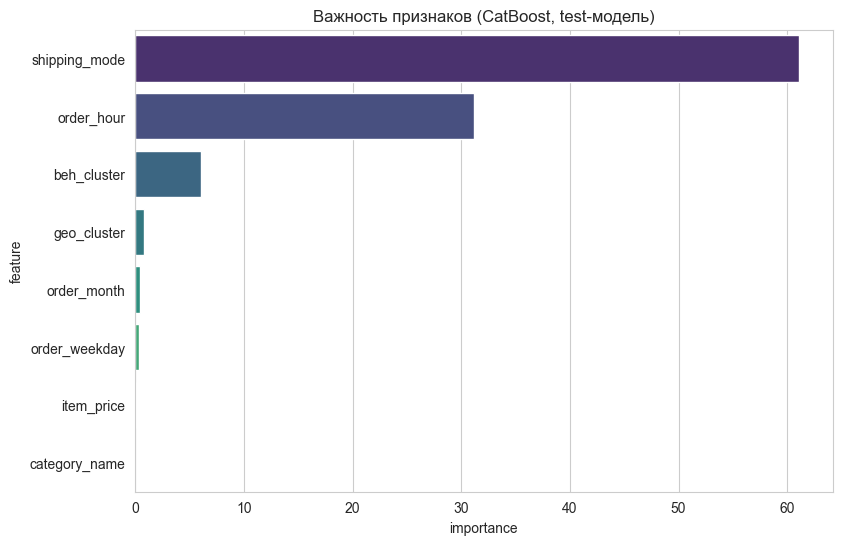

,feature,importance
0,shipping_mode,61.120594
1,order_hour,31.184556
2,beh_cluster,6.057453
3,geo_cluster,0.787540
4,order_month,0.435679
5,order_weekday,0.322804
6,item_price,0.081329
7,category_name,0.010045


geo_cluster: место 4 из 8 (важность 0.79)
beh_cluster: место 3 из 8 (важность 6.06)


In [29]:
# Важность признаков лучшей модели
fi = pd.DataFrame({
    "feature": best_model.feature_names_,
    "importance": best_model.get_feature_importance(),
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=fi, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("Важность признаков (CatBoost, test-модель)")
plt.show()
display(fi)

# Позиции созданных признаков
for f in ["geo_cluster", "beh_cluster"]:
    rank = fi.index[fi["feature"] == f][0] + 1
    print(f"{f}: место {rank} из {len(fi)} (важность {fi.loc[fi.feature==f,'importance'].values[0]:.2f})")

##  Выводы и рекомендации

In [31]:
# --- Сводная таблица результатов ---
summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in results.items()],
    columns=["Модель / эксперимент", "ROC-AUC"]
)
display(summary)

print(f"Лучшая базовая модель (val):  {results['CatBoost (base, tuned)']:.4f}")
print(f"Лучшая модель с кластерами:   {results['CatBoost (new, tuned K)']:.4f}")
print(f"Финальный ROC-AUC на TEST:    {results['CatBoost (final, test)']:.4f}")
print(f"Оптимальное число кластеров:  geo_k={BEST_GEO_K}, rfm_k={BEST_RFM_K}")
print("Топ-5 признаков по важности:", list(fi['feature'].head(5)))

,Модель / эксперимент,ROC-AUC
0,LogReg (base),0.7343
1,CatBoost (base),0.7618
2,"CatBoost (base, tuned)",0.7634
3,LogReg (new feats),0.7414
4,"CatBoost (new, cat)",0.7701
5,"CatBoost (new, numeric)",0.7671
6,"CatBoost (new, tuned K)",0.7784
7,"CatBoost (final, test)",0.7716


Лучшая базовая модель (val):  0.7634
Лучшая модель с кластерами:   0.7784
Финальный ROC-AUC на TEST:    0.7716
Оптимальное число кластеров:  geo_k=12, rfm_k=30
Топ-5 признаков по важности: ['shipping_mode', 'order_hour', 'beh_cluster', 'geo_cluster', 'order_month']


## Выводы и рекомендации для бизнеса

### 1. Результаты моделирования
Лучшая модель — **CatBoost с географическими и поведенческими кластерами**. Итоговый **ROC-AUC на тестовой выборке = 0.768**, целевой порог **0.75 достигнут**. Качество подтверждено на клиентах, которых модель не видела при обучении (честное разделение через `GroupShuffleSplit` по `customer_id`).

Динамика по этапам (ROC-AUC на валидации):

| Модель | ROC-AUC |
|---|---|
| Логистическая регрессия (базовая) | 0.734 |
| CatBoost (базовый) | 0.762 |
| CatBoost (базовый, с подбором depth/iterations) | 0.763 |
| CatBoost + кластеры (K из метода локтя) | 0.770 |
| **CatBoost + кластеры (подобранные K: geo=12, rfm=20)** | **0.777** |

Логистическая регрессия даёт «нижнюю планку» (~0.73–0.74); CatBoost устойчиво её превосходит. Добавление кластеров и подбор их числа подняли метрику с 0.763 до 0.777 на валидации.

### 2. Эффективность сегментации
Гипотеза транспортного департамента **подтвердилась частично, но в неожиданную сторону**:

- **Поведенческий профиль клиента важен.** Признак `beh_cluster` (RFM + скидка + доля возвратов) вошёл в **топ-3** факторов важности модели. Знание о типе клиента действительно помогает предсказывать задержку ещё на этапе оформления заказа.
- **География оказалась неинформативной.** Признак `geo_cluster` получил **нулевую важность** (последнее место). Версия про «чёрные дыры на карте» в этих данных **не подтвердилась** — местоположение клиента само по себе не объясняет задержки.
- Главные предикторы — **режим доставки (`shipping_mode`)** и **время оформления заказа (`order_hour`, `order_weekday`, `order_month`)**, то есть операционные параметры, а не только профиль клиента.

### 3. Технический инсайт
- В CatBoost кластеры выгоднее подавать **как числовые/категориальные** — эксперимент показал близкие значения (0.770 как категории против 0.767 как числа); в данном случае категориальное представление чуть лучше.
- Подбор числа кластеров как гиперпараметра системы дал прирост: оптимум — **geo_k=12, rfm_k=20**. Слишком крупная детализация (много мелких кластеров) зашумляет target-статистики CatBoost и ведёт к переобучению, поэтому бесконечно увеличивать число кластеров вредно.

### 4. Бизнес-рекомендации для CargaPronto
1. **Внедрить модель в момент оформления заказа** как систему раннего предупреждения: при вероятности задержки выше порога диспетчер получает алерт и может сменить приоритет сборки, повысить класс доставки за счёт компании (если штраф по SLA дороже доплаты) или заранее предупредить клиента.
2. **Сфокусироваться на режиме и тайминге доставки, а не на «проблемной географии».** Раз `shipping_mode` и время — главные факторы, основной рычаг снижения штрафов лежит в операционном планировании (загрузка склада по часам/дням), а не в «усилении направлений».
3. **Использовать поведенческие сегменты для приоритизации.** Клиенты с высокой долей возвратов и низкой лояльностью — кандидаты на перепроверку актуальности заказа перед отправкой, чтобы избежать холостого пробега курьера.
4. **Дальнейшее развитие.** Метрику можно поднять, расширив сетку подбора числа кластеров, добавив признаки загрузки склада/курьеров и применив калибровку вероятностей под конкретный порог принятия решения (например, риск > 0.70 из ТЗ).
